In [ ]:
!pip install rdflib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 565.1/565.1 kB 6.8 MB/s eta 0:00:00


In [1]:
from rdflib import Graph, Namespace, URIRef, Literal
from rdflib.namespace import RDF, XSD
from datetime import datetime, timedelta
import random
import hashlib

# Namespaces
ex = Namespace("http://example.org/")
student = Namespace("http://example.org/student/")
event = Namespace("http://example.org/event/")
time = Namespace("http://example.org/time/")
prop = Namespace("http://example.org/prop/")

# Initialize graph
g = Graph()
g.bind("ex", ex)
g.bind("student", student)
g.bind("event", event)
g.bind("time", time)
g.bind("prop", prop)

# Student
student_id = student.StudentU00

# Helper functions
def generate_event_uri(event_type, timestamp):
    raw = f"{event_type}_{timestamp.isoformat()}_{random.randint(0,9999)}"
    return event[hashlib.md5(raw.encode()).hexdigest()]

def add_event(g, student_id, event_type, props, timestamp):
    e_uri = generate_event_uri(event_type, timestamp)
    g.add((student_id, ex.performs, e_uri))
    g.add((e_uri, RDF.type, event[event_type]))
    g.add((e_uri, time.hasTime, Literal(timestamp.isoformat(), datatype=XSD.dateTime)))
    for p, v in props.items():
        g.add((e_uri, prop[p], Literal(v)))
    return e_uri

# Simulation parameters
start_date = datetime(2024, 1, 1)
weeks = 4
days_per_week = 7
modalities = ["PhoneLockEvent", "PhoneChargeEvent", "BluetoothInteractionEvent",
              "SMSEvent", "PhoneCallEvent", "CalendarEvent", "AppUsageEvent", "WifiLocationEvent", "WifiEvent", "GPSEvent"]

# Simulation function
def simulate_week(g, student_id, start_date, exam_week=False):
    for day_offset in range(days_per_week):
        day = start_date + timedelta(days=day_offset)
        for _ in range(10):  # 10 readings per modality
            ts = day + timedelta(minutes=random.randint(0, 1440))  # random time in day

            # PhoneLock Event
            add_event(g, student_id, "PhoneLockEvent", {"state": "locked"}, ts)
            add_event(g, student_id, "PhoneLockEvent", {"state": "unlocked"}, ts + timedelta(minutes=5))

            # PhoneCharge Event
            add_event(g, student_id, "PhoneChargeEvent", {"state": "charging"}, ts)
            add_event(g, student_id, "PhoneChargeEvent", {"state": "discharging"}, ts + timedelta(minutes=10))

            # Bluetooth Interaction
            bt_count = random.randint(1, 2) if exam_week else random.randint(5, 10)
            for _ in range(bt_count):
                add_event(g, student_id, "BluetoothInteractionEvent", {"device": f"BT_{random.randint(1000,9999)}"}, ts)

            # SMS Event
            sms_count = random.randint(1, 2) if exam_week else random.randint(5, 10)
            for _ in range(sms_count):
                to = "family" if exam_week else f"contact_{random.randint(1,50)}"
                add_event(g, student_id, "SMSEvent", {"toAddress": to}, ts)

            # Call Event
            call_count = 1 if exam_week else random.randint(5, 10)
            for _ in range(call_count):
                to = "family" if exam_week else f"contact_{random.randint(1,50)}"
                add_event(g, student_id, "PhoneCallEvent", {"toNumber": to, "duration": random.randint(30, 300)}, ts)

            # Calendar Event
            if exam_week:
                add_event(g, student_id, "CalendarEvent", {"eventName": "Exam"}, ts)
            else:
                ev = random.choice(["Lecture", "Meeting", "Sports", "Hangout"])
                add_event(g, student_id, "CalendarEvent", {"eventName": ev}, ts)

            # App Usage
            app_count = random.randint(2, 3) if exam_week else random.randint(8, 12)
            for _ in range(app_count):
                app = "edu_app" if exam_week else f"app_{random.randint(1,100)}"
                add_event(g, student_id, "AppUsageEvent", {"packageName": app}, ts)

            # Wifi Location
            add_event(g, student_id, "WifiLocationEvent", {"place": random.choice(["Home", "Library", "Cafe"])}, ts)

            # Wifi Event
            add_event(g, student_id, "WifiEvent", {"bssid": f"BSSID_{random.randint(1000,9999)}"}, ts)

            # GPS Event
            add_event(g, student_id, "GPSEvent", {"travelstate": random.choice(["moving", "stationary"])}, ts)

# Simulate 4 weeks
simulate_week(g, student_id, start_date, exam_week=False)  # Week 1
simulate_week(g, student_id, start_date + timedelta(7), exam_week=False)  # Week 2
simulate_week(g, student_id, start_date + timedelta(14), exam_week=True)  # Week 3 (exam)
simulate_week(g, student_id, start_date + timedelta(21), exam_week=False)  # Week 4

print(f"Total triples: {len(g)}")


Total triples: 39492


In [ ]:
# Save the graph if needed
g.serialize(destination="simulated_studentlife_tkg.ttl", format="turtle")


<Graph identifier=Nbee86118cabd40d3b2a64db94cb73b66 (<class 'rdflib.graph.Graph'>)>

In [2]:
from collections import defaultdict
from rdflib import Graph, URIRef
from datetime import datetime

# Configuration
modalities_of_interest = ["PhoneCallEvent", "SMSEvent", "BluetoothInteractionEvent", "AppUsageEvent", "PhoneLockEvent"]

# Helper: Get week number from timestamp
def get_week_number(timestamp, start_date):
    delta = timestamp - start_date
    return delta.days // 7 + 1  # Week 1, 2, 3, 4

# Initialize
week_graphs = defaultdict(Graph)

# Loop over full graph
for s, p, o in g:
    # We are interested in events that are instances of event types
    if p == RDF.type and any(modality in o.split("#")[-1] for modality in modalities_of_interest):
        event_uri = s
        # Find the timestamp
        for _, _, ts_literal in g.triples((event_uri, time.hasTime, None)):
            timestamp = datetime.fromisoformat(str(ts_literal))
            week_num = get_week_number(timestamp, start_date)
            week_graphs[week_num].add((s, p, o))
            # Also add other properties related to this event
            for _, pred, obj in g.triples((event_uri, None, None)):
                week_graphs[week_num].add((event_uri, pred, obj))
            for subj, pred, _ in g.triples((None, None, event_uri)):
                week_graphs[week_num].add((subj, pred, event_uri))

# Save or use the weekly graphs
for week_num, wg in week_graphs.items():
    print(f"Week {week_num}: {len(wg)} triples")
    # Uncomment to save:
    # wg.serialize(destination=f"studentlife_week{week_num}.ttl", format="turtle")


Week 1: 10069 triples
Week 4: 10033 triples
Week 3: 2418 triples
Week 2: 10252 triples


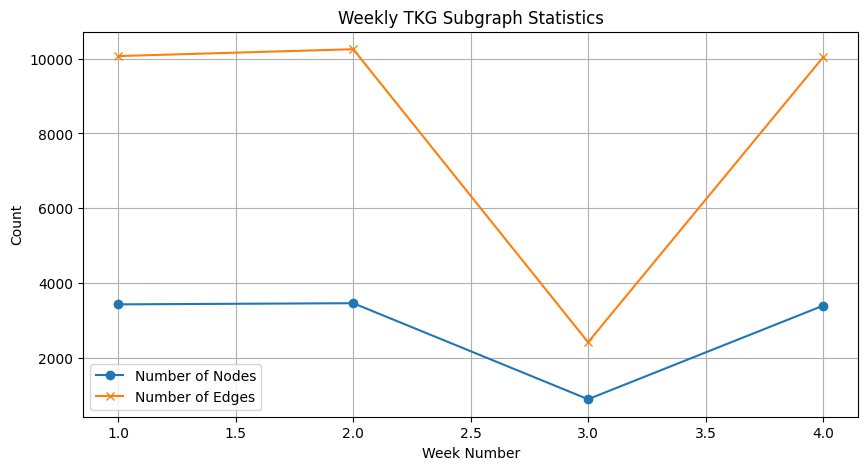

In [3]:
import matplotlib.pyplot as plt

# Assuming week_graphs is the dict {week_num: Graph}

week_nums = []
node_counts = []
edge_counts = []

for week_num, wg in sorted(week_graphs.items()):
    nodes = set()
    edges = 0
    for s, p, o in wg:
        nodes.add(s)
        nodes.add(o)
        edges += 1
    week_nums.append(week_num)
    node_counts.append(len(nodes))
    edge_counts.append(edges)

plt.figure(figsize=(10,5))
plt.plot(week_nums, node_counts, marker='o', label='Number of Nodes')
plt.plot(week_nums, edge_counts, marker='x', label='Number of Edges')
plt.title("Weekly TKG Subgraph Statistics")
plt.xlabel("Week Number")
plt.ylabel("Count")
plt.legend()
plt.grid()
plt.show()


Similarity scoring

In [4]:
import numpy as np
import networkx as nx
from networkx import average_clustering, density
from scipy.spatial.distance import cityblock

def rdflib_to_networkx(graph):
    """Convert RDFLib Graph to NetworkX graph."""
    G = nx.Graph()
    for s, p, o in graph:
        G.add_edge(str(s), str(o), predicate=str(p))
    return G

week_nx = {week: rdflib_to_networkx(week_graphs[week]) for week in [1,2,3,4]}

# --- Count triples directly ---
def count_subgraph_triples(wg):
    return len(list(wg.triples((None, None, None))))

# --- Node-level features ---
def graph_features(G):
    num_nodes = G.number_of_nodes()
    num_edges = G.number_of_edges()
    avg_degree = sum(dict(G.degree()).values()) / num_nodes if num_nodes > 0 else 0
    clustering = average_clustering(G) if num_nodes > 1 else 0
    dens = density(G)
    return np.array([num_nodes, num_edges, avg_degree, clustering, dens])

# --- Similarity calculations ---
def calculate_similarity(curr, ref, max_delta):
    abs_diff = abs(curr - ref)
    similarity = 1 - (abs_diff / max_delta) if max_delta > 0 else 1.0
    return max(0, min(1, similarity))

def manhattan_similarity(feat1, feat2, max_distance):
    distance = cityblock(feat1, feat2)
    similarity = 1 - (distance / max_distance) if max_distance > 0 else 1.0
    return max(0, similarity)

# === Combined Analysis ===
def combined_graph_analysis(week_graphs, week_nx):
    # --- Graph-level (Triple Counts) ---
    triple_counts = {week: count_subgraph_triples(wg) for week, wg in week_graphs.items()}

    # --- Node-level (Graph Features) ---
    week_features = {week: graph_features(G) for week, G in week_nx.items()}

    # --- Precompute maximums for normalization ---
    delta_triples = {week: triple_counts[week] - triple_counts[week-1]
                     for week in sorted(triple_counts.keys()) if week != 1}
    max_delta_triples = max(abs(delta) for delta in delta_triples.values())

    all_distances = []
    for week in sorted(week_features.keys()):
        if week == 1:
            continue
        curr_feat = week_features[week].flatten()
        ref_feat = week_features[1].flatten()
        prev_feat = week_features[week-1].flatten() if (week-1) in week_features else None

        if prev_feat is not None:
            all_distances.append(cityblock(curr_feat, prev_feat))
        all_distances.append(cityblock(curr_feat, ref_feat))

    max_distance = max(all_distances)

    # --- Report ---
    for week in sorted(week_graphs.keys()):
        print(f"\n=== Week {week} ===")

        if week == 1:
            print(f"Triples: {triple_counts[week]}")
            print(f"Node Features: {week_features[week]}")
            continue

        # --- Graph-level ---
        curr_triples = triple_counts[week]
        prev_triples = triple_counts[week-1]
        ref_triples = triple_counts[1]

        sim_prev = calculate_similarity(curr_triples, prev_triples, max_delta_triples)
        sim_ref = calculate_similarity(curr_triples, ref_triples, max_delta_triples)

        print(f"Triples: {curr_triples}")
        print(f"Δ Triples from Previous: {curr_triples - prev_triples}")
        print(f"Triple Similarity to Previous: {sim_prev:.3f}")
        print(f"Triple Similarity to Week 1: {sim_ref:.3f}")

        # --- Node-level ---
        curr_feat = week_features[week].flatten()
        prev_feat = week_features[week-1].flatten()
        ref_feat = week_features[1].flatten()

        node_sim_prev = manhattan_similarity(curr_feat, prev_feat, max_distance)
        node_sim_ref = manhattan_similarity(curr_feat, ref_feat, max_distance)

        print(f"Node Features: {curr_feat}")
        print(f"Node Similarity to Previous: {node_sim_prev:.3f}")
        print(f"Node Similarity to Week 1: {node_sim_ref:.3f}")

combined_graph_analysis(week_graphs, week_nx)



=== Week 1 ===
Triples: 10305
Node Features: [3.51900000e+03 1.03050000e+04 5.85677749e+00 0.00000000e+00
 1.66480315e-03]

=== Week 2 ===
Triples: 10251
Δ Triples from Previous: -54
Triple Similarity to Previous: 0.993
Triple Similarity to Week 1: 0.993
Node Features: [3.47300000e+03 1.02510000e+04 5.90325367e+00 0.00000000e+00
 1.70024587e-03]
Node Similarity to Previous: 0.990
Node Similarity to Week 1: 0.990

=== Week 3 ===
Triples: 2474
Δ Triples from Previous: -7777
Triple Similarity to Previous: 0.000
Triple Similarity to Week 1: 0.000
Node Features: [9.13000000e+02 2.47400000e+03 5.41949617e+00 0.00000000e+00
 5.94243001e-03]
Node Similarity to Previous: 0.010
Node Similarity to Week 1: 0.000

=== Week 4 ===
Triples: 10207
Δ Triples from Previous: 7733
Triple Similarity to Previous: 0.006
Triple Similarity to Week 1: 0.987
Node Features: [3.46900000e+03 1.02070000e+04 5.88469300e+00 0.00000000e+00
 1.69685496e-03]
Node Similarity to Previous: 0.014
Node Similarity to Week 1: 0

In [9]:
!pip install karateclub


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.5/64.5 kB 1.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 50.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 22.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 45.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.7/161.7 kB

In [7]:
# !pip install --upgrade numpy
# pip install --upgrade pandas
!pip install numpy==1.23.5

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 60.3 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.22.4
    Uninstalling numpy-1.22.4:
      Successfully uninstalled numpy-1.22.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
karateclub 1.3.3 requires numpy<1.23.0, but you have numpy 1.23.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 1.3.5 which is incompatible.
statsmodels 0.14.4 requires pandas!=2.1.0,>=1.4, but you have pandas 1.3.5 which is incompatible.
pymc 5.21.2 requires numpy>=1.25.0, but you have numpy 1.23.5 which is incompatible.
imbalanced-learn 0.13.0 requires numpy<3,>=1.24.3, but you have numpy 1.23.5 which is incompatible.
scikit-image 0.25.2 requires networkx>=3.0, but you have networkx 2.6.3 which is incompatible.
scikit-image 0.25.2 requires numpy>=

In [6]:
import numpy as np
import networkx as nx
from networkx import average_clustering, density
from scipy.spatial.distance import cityblock
from sklearn.metrics.pairwise import cosine_similarity
from karateclub import Graph2Vec, Node2Vec  # New: KarateClub for embeddings

# def rdflib_to_networkx(graph):
#     """Convert RDFLib Graph to NetworkX graph."""
#     G = nx.Graph()
#     for s, p, o in graph:
#         G.add_edge(str(s), str(o), predicate=str(p))
#     return G
def rdflib_to_networkx(graph):
    """Convert RDFLib Graph to NetworkX graph."""
    G = nx.Graph()
    for s, p, o in graph:
        G.add_edge(str(s), str(o), predicate=str(p))
    G = nx.convert_node_labels_to_integers(G)  # <-- ADD THIS LINE
    return G


week_nx = {week: rdflib_to_networkx(week_graphs[week]) for week in [1,2,3,4]}

# --- Graph2Vec embeddings ---
def compute_graph2vec_embeddings(week_nx):
    graphs = list(week_nx.values())
    model = Graph2Vec(dimensions=128, workers=1, epochs=10)
    model.fit(graphs)
    embeddings = model.get_embedding()
    return {week: embeddings[i] for i, week in enumerate(week_nx.keys())}

# # --- Node2Vec embeddings (aggregated per graph) ---
# def compute_node2vec_aggregated_embeddings(week_nx):
#     week_node_embeds = {}
#     for week, G in week_nx.items():
#         if G.number_of_nodes() == 0:
#             week_node_embeds[week] = np.zeros(128)
#             continue
#         model = Node2Vec(dimensions=128, walk_length=10, num_walks=80, workers=1)
#         model.fit(G)
#         node_embeddings = model.get_embedding()
#         mean_embedding = np.mean(node_embeddings, axis=0)  # Aggregate by mean
#         week_node_embeds[week] = mean_embedding
#     return week_node_embeds

def compute_node2vec_aggregated_embeddings(week_nx):
    week_node_embeds = {}
    for week, G in week_nx.items():
        if G.number_of_nodes() == 0:
            week_node_embeds[week] = np.zeros(128)
            continue
        model = Node2Vec(dimensions=128, walk_length=10, workers=1)  # <-- fixed
        model.fit(G)
        node_embeddings = model.get_embedding()
        mean_embedding = np.mean(node_embeddings, axis=0)
        week_node_embeds[week] = mean_embedding
    return week_node_embeds


# === Combined Analysis ===
def combined_graph_analysis(week_graphs, week_nx):
    # --- Graph2Vec and Node2Vec ---
    graph_embeddings = compute_graph2vec_embeddings(week_nx)
    node_agg_embeddings = compute_node2vec_aggregated_embeddings(week_nx)

    # --- Report ---
    for week in sorted(week_graphs.keys()):
        print(f"\n=== Week {week} ===")

        if week == 1:
            print(f"Graph Embedding (Week 1): {graph_embeddings[week][:5]}...")  # Only show first 5 dims
            print(f"Node Aggregated Embedding (Week 1): {node_agg_embeddings[week][:5]}...")
            continue

        # --- Graph-level Similarity ---
        curr_graph_emb = graph_embeddings[week].reshape(1, -1)
        prev_graph_emb = graph_embeddings[week-1].reshape(1, -1)
        ref_graph_emb = graph_embeddings[1].reshape(1, -1)

        sim_prev_graph = cosine_similarity(curr_graph_emb, prev_graph_emb)[0][0]
        sim_ref_graph = cosine_similarity(curr_graph_emb, ref_graph_emb)[0][0]

        print(f"Graph-level Cosine Similarity to Previous: {sim_prev_graph:.3f}")
        print(f"Graph-level Cosine Similarity to Week 1: {sim_ref_graph:.3f}")

        # --- Node-level Similarity ---
        curr_node_emb = node_agg_embeddings[week].reshape(1, -1)
        prev_node_emb = node_agg_embeddings[week-1].reshape(1, -1)
        ref_node_emb = node_agg_embeddings[1].reshape(1, -1)

        sim_prev_node = cosine_similarity(curr_node_emb, prev_node_emb)[0][0]
        sim_ref_node = cosine_similarity(curr_node_emb, ref_node_emb)[0][0]

        print(f"Node-level Cosine Similarity to Previous: {sim_prev_node:.3f}")
        print(f"Node-level Cosine Similarity to Week 1: {sim_ref_node:.3f}")

combined_graph_analysis(week_graphs, week_nx)



=== Week 1 ===
Graph Embedding (Week 1): [-0.16781117  0.54150105  1.2175924  -0.44960442 -0.8724889 ]...
Node Aggregated Embedding (Week 1): [-0.0795388   0.01139536 -0.23734479 -0.0530477  -0.05740703]...

=== Week 2 ===
Graph-level Cosine Similarity to Previous: 0.178
Graph-level Cosine Similarity to Week 1: 0.178
Node-level Cosine Similarity to Previous: 0.025
Node-level Cosine Similarity to Week 1: 0.025

=== Week 3 ===
Graph-level Cosine Similarity to Previous: 0.314
Graph-level Cosine Similarity to Week 1: 0.330
Node-level Cosine Similarity to Previous: 0.088
Node-level Cosine Similarity to Week 1: -0.098

=== Week 4 ===
Graph-level Cosine Similarity to Previous: 0.335
Graph-level Cosine Similarity to Week 1: 0.208
Node-level Cosine Similarity to Previous: -0.047
Node-level Cosine Similarity to Week 1: 0.084


In [6]:
import numpy as np
import networkx as nx
from networkx import average_clustering, density
from scipy.spatial.distance import cityblock
from sklearn.metrics.pairwise import cosine_similarity
from karateclub import Graph2Vec, Node2Vec

# def rdflib_to_networkx(graph):
#     """Convert RDFLib Graph to NetworkX graph."""
#     G = nx.Graph()
#     for s, p, o in graph:
#         G.add_edge(str(s), str(o), predicate=str(p))
#     return G
def rdflib_to_networkx(graph):
    """Convert RDFLib Graph to NetworkX graph."""
    G = nx.Graph()
    for s, p, o in graph:
        G.add_edge(str(s), str(o), predicate=str(p))
    G = nx.convert_node_labels_to_integers(G)  # <-- ADD THIS LINE
    return G

week_nx = {week: rdflib_to_networkx(week_graphs[week]) for week in [1,2,3,4]}

# --- Precompute Graph2Vec embeddings ---
def compute_graph2vec_embeddings(week_nx):
    graphs = list(week_nx.values())
    model = Graph2Vec(dimensions=128, workers=1, epochs=10)
    model.fit(graphs)
    embeddings = model.get_embedding()
    return {week: embeddings[i] for i, week in enumerate(week_nx.keys())}

# --- Precompute Node2Vec embeddings and aggregate ---
# def compute_node2vec_embeddings(week_nx):
#     aggregated_embeddings = {}
#     for week, G in week_nx.items():
#         if G.number_of_nodes() == 0:
#             aggregated_embeddings[week] = np.zeros(128)
#             continue
#         model = Node2Vec(dimensions=128, walk_length=10, num_walks=80, workers=1)
#         model.fit(G)
#         node_embeds = model.get_embedding()
#         mean_embed = np.mean(node_embeds, axis=0)
#         aggregated_embeddings[week] = mean_embed
#     return aggregated_embeddings

def compute_node2vec_aggregated_embeddings(week_nx):
    week_node_embeds = {}
    for week, G in week_nx.items():
        if G.number_of_nodes() == 0:
            week_node_embeds[week] = np.zeros(128)
            continue
        model = Node2Vec(dimensions=128, walk_length=10, workers=1)  # <-- fixed
        model.fit(G)
        node_embeddings = model.get_embedding()
        mean_embedding = np.mean(node_embeddings, axis=0)
        week_node_embeds[week] = mean_embedding
    return week_node_embeds


# === Combined Analysis ===
def combined_graph_analysis(week_graphs, week_nx):
    print("Fitting Graph2Vec...")
    graph_embeddings = compute_graph2vec_embeddings(week_nx)

    print("Fitting Node2Vec per graph...")
    # node_embeddings = compute_node2vec_embeddings(week_nx)
    node_embeddings = compute_node2vec_aggregated_embeddings(week_nx)

    print("\nStarting Week-wise Comparison...\n")

    for week in sorted(week_graphs.keys()):
        print(f"\n=== Week {week} ===")

        if week == 1:
            print(f"Graph Embedding (sample): {graph_embeddings[week][:5]}...")
            print(f"Node Aggregated Embedding (sample): {node_embeddings[week][:5]}...")
            continue

        # Graph-level similarities
        curr_graph_emb = graph_embeddings[week].reshape(1, -1)
        prev_graph_emb = graph_embeddings[week-1].reshape(1, -1)
        ref_graph_emb = graph_embeddings[1].reshape(1, -1)

        sim_graph_prev = cosine_similarity(curr_graph_emb, prev_graph_emb)[0][0]
        sim_graph_ref = cosine_similarity(curr_graph_emb, ref_graph_emb)[0][0]

        print(f"Graph2Vec Similarity to Previous Week: {sim_graph_prev:.3f}")
        print(f"Graph2Vec Similarity to Week 1: {sim_graph_ref:.3f}")

        # Node-level similarities
        curr_node_emb = node_embeddings[week].reshape(1, -1)
        prev_node_emb = node_embeddings[week-1].reshape(1, -1)
        ref_node_emb = node_embeddings[1].reshape(1, -1)

        sim_node_prev = cosine_similarity(curr_node_emb, prev_node_emb)[0][0]
        sim_node_ref = cosine_similarity(curr_node_emb, ref_node_emb)[0][0]

        print(f"Node2Vec Similarity to Previous Week: {sim_node_prev:.3f}")
        print(f"Node2Vec Similarity to Week 1: {sim_node_ref:.3f}")

combined_graph_analysis(week_graphs, week_nx)


ImportError: numpy.core.multiarray failed to import

In [ ]:
# # --- Just count total triples in each subgraph ---
# def count_subgraph_triples(wg):
#     return len(list(wg.triples((None, None, None))))

# # --- Analyze ---
# triple_counts = {}

# for week_num, wg in week_graphs.items():
#     n_triples = count_subgraph_triples(wg)
#     triple_counts[week_num] = n_triples

# # --- Compute volatility ---
# print("\nSubgraph Triple Volatility:")
# for week in sorted(triple_counts.keys()):
#     if week == 1:
#         continue
#     prev_triples = triple_counts[week-1]
#     curr_triples = triple_counts[week]

#     delta = curr_triples - prev_triples
#     ratio = curr_triples / prev_triples if prev_triples != 0 else 0

#     print(f"Week {week}:")
#     print(f"  Δ triples = {delta}")
#     print(f"  Ratio = {ratio:.3f}")

# --- Count total triples in each subgraph ---
def count_subgraph_triples(wg):
    return len(list(wg.triples((None, None, None))))

# --- Analyze ---
triple_counts = {}

# First, count the total triples in each week
for week_num, wg in week_graphs.items():
    n_triples = count_subgraph_triples(wg)
    triple_counts[week_num] = n_triples

# --- Compute volatility ---
# Calculate the differences and ratios (just like you did)
print("\nSubgraph Triple Volatility:")
delta_triples = {}  # Store the change in triples between weeks
max_delta_triples = 0  # To normalize similarity

# Calculate the volatility (delta in triples) for each week
for week in sorted(triple_counts.keys()):
    if week == 1:
        continue

    prev_triples = triple_counts[week-1]
    curr_triples = triple_counts[week]

    # Calculate the absolute change in triples
    delta = curr_triples - prev_triples
    ratio = curr_triples / prev_triples if prev_triples != 0 else 0

    # Store the delta for similarity calculations
    delta_triples[week] = delta
    max_delta_triples = max(max_delta_triples, abs(delta))  # Update max delta

    print(f"Week {week}:")
    print(f"  Δ triples = {delta}")
    print(f"  Ratio = {ratio:.3f}")

# --- Compute similarity score for triple count ---
def calculate_similarity(curr_triples, ref_triples, max_delta):
    # Calculate absolute difference
    abs_diff = abs(curr_triples - ref_triples)

    # Normalize the similarity to be between 0 and 1
    similarity = 1 - (abs_diff / max_delta) if max_delta > 0 else 1.0  # If no change, similarity is 1

    # Clamp the similarity to ensure it's between 0 and 1
    similarity = max(0, min(1, similarity))  # Ensure similarity is between 0 and 1

    return similarity

# Compute similarity to previous week and first week
for week in sorted(triple_counts.keys()):
    print(f"\n--- Week {week} ---")
    if week == 1:
        continue

    curr_triples = triple_counts[week]
    ref_triples = triple_counts[1]  # Compare with Week 1
    prev_triples = triple_counts[week-1]  # Compare with previous week

    # Calculate similarity to previous week
    sim_prev = calculate_similarity(curr_triples, prev_triples, max_delta_triples)
    print(f"Similarity to Previous Week: {sim_prev:.3f}")

    # Calculate similarity to first week
    sim_ref = calculate_similarity(curr_triples, ref_triples, max_delta_triples)
    print(f"Similarity to Week 1: {sim_ref:.3f}")



Subgraph Triple Volatility:
Week 2:
  Δ triples = -206
  Ratio = 0.980
Week 3:
  Δ triples = -7807
  Ratio = 0.233
Week 4:
  Δ triples = 7662
  Ratio = 4.227

--- Week 1 ---

--- Week 2 ---
Similarity to Previous Week: 0.974
Similarity to Week 1: 0.974

--- Week 3 ---
Similarity to Previous Week: 0.000
Similarity to Week 1: 0.000

--- Week 4 ---
Similarity to Previous Week: 0.019
Similarity to Week 1: 0.955


In [ ]:
from networkx import average_clustering, density
from scipy.spatial.distance import cityblock
import numpy as np

def graph_features(G):
    # Extracting graph features: number of nodes, edges, average degree, clustering, and density
    num_nodes = G.number_of_nodes()
    num_edges = G.number_of_edges()
    avg_degree = sum(dict(G.degree()).values()) / num_nodes if num_nodes > 0 else 0
    clustering = average_clustering(G) if num_nodes > 1 else 0
    dens = density(G)
    return np.array([num_nodes, num_edges, avg_degree, clustering, dens])

# Extract features week-wise
week_features = {}
for week, G in week_nx.items():
    feat = graph_features(G)
    print(f"Week {week}: {feat}")
    week_features[week] = feat

# Function to compute normalized Manhattan-based similarity score
def manhattan_similarity(feat1, feat2, max_distance):
    # Calculate the Manhattan distance
    distance = cityblock(feat1, feat2)

    # Normalize the similarity to be between 0 and 1
    similarity = 1 - (distance / max_distance)  # Inverse scaling to make similarity closer to 1 for similar vectors
    similarity = max(0, similarity)  # Ensure similarity is non-negative
    return similarity

# Compare with Week 1 and previous week
all_distances = []  # To store all Manhattan distances for max normalization

# First, calculate all the pairwise Manhattan distances
for week in sorted(week_features.keys()):
    if week == 1:
        continue

    curr_feat = week_features[week].flatten()  # Flatten to 1D array
    ref_feat = week_features[1].flatten()      # Flatten to 1D array
    prev_feat = week_features[week-1].flatten() if (week-1) in week_features else None

    # Store distances for normalization later
    if prev_feat is not None:
        all_distances.append(cityblock(curr_feat, prev_feat))

    all_distances.append(cityblock(curr_feat, ref_feat))

# Normalize based on the maximum distance found
max_distance = max(all_distances)

# Now, compute the similarity scores using the normalized distance
for week in sorted(week_features.keys()):
    print(f"\n--- Week {week} ---")
    if week == 1:
        continue

    curr_feat = week_features[week].flatten()  # Flatten to 1D array
    ref_feat = week_features[1].flatten()      # Flatten to 1D array
    prev_feat = week_features[week-1].flatten() if (week-1) in week_features else None

    if prev_feat is not None:
        sim_prev = manhattan_similarity(curr_feat, prev_feat, max_distance)
        print(f"Manhattan Similarity to Previous Week: {sim_prev:.3f}")

    sim_ref = manhattan_similarity(curr_feat, ref_feat, max_distance)
    print(f"Manhattan Similarity to Week 1: {sim_ref:.3f}")


Week 1: [3.52000000e+03 1.03870000e+04 5.90170455e+00 0.00000000e+00
 1.67709706e-03]
Week 4: [3.39800000e+03 1.00360000e+04 5.90700412e+00 0.00000000e+00
 1.73888847e-03]
Week 3: [8.91000000e+02 2.37400000e+03 5.32884400e+00 0.00000000e+00
 5.98746516e-03]
Week 2: [3.45400000e+03 1.01810000e+04 5.89519398e+00 0.00000000e+00
 1.70726730e-03]

--- Week 1 ---

--- Week 2 ---
Manhattan Similarity to Previous Week: 0.974
Manhattan Similarity to Week 1: 0.974

--- Week 3 ---
Manhattan Similarity to Previous Week: 0.026
Manhattan Similarity to Week 1: 0.000

--- Week 4 ---
Manhattan Similarity to Previous Week: 0.044
Manhattan Similarity to Week 1: 0.956


In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import cdist

# Feature matrix (4 samples, 5 features)
features_matrix = np.array([
    [3.52000000e+03, 1.03870000e+04, 5.90170455e+00, 0.00000000e+00, 1.67709706e-03],  # Sample 1
    [3.39800000e+03, 1.00360000e+04, 5.90700412e+00, 0.00000000e+00, 1.73888847e-03],  # Sample 2
    [8.91000000e+02, 2.37400000e+03, 5.32884400e+00, 0.00000000e+00, 5.98746516e-03],  # Sample 3
    [3.45400000e+03, 1.01810000e+04, 5.89519398e+00, 0.00000000e+00, 1.70726730e-03]   # Sample 4
])

# Normalize the feature matrix
scaler = StandardScaler()
normalized_features = scaler.fit_transform(features_matrix)

# Compute pairwise Euclidean distances
euclidean_distances = cdist(normalized_features, normalized_features, metric='euclidean')
print("Euclidean Distance Matrix:")
print(euclidean_distances)

# Compute pairwise Manhattan distances
manhattan_distances = cdist(normalized_features, normalized_features, metric='cityblock')
print("\nManhattan Distance Matrix:")
print(manhattan_distances)

# Now let's look for the sample most different from others
# For each sample, compute its average distance to all other samples
euclidean_avg_distances = np.mean(euclidean_distances, axis=1)
manhattan_avg_distances = np.mean(manhattan_distances, axis=1)

print("\nAverage Euclidean Distances:")
print(euclidean_avg_distances)

print("\nAverage Manhattan Distances:")
print(manhattan_avg_distances)

# Determine which sample has the highest distance (i.e., outlier)
outlier_euclidean = np.argmax(euclidean_avg_distances)
outlier_manhattan = np.argmax(manhattan_avg_distances)

print(f"\nSample with highest Euclidean distance (outlier): {outlier_euclidean + 1}")
print(f"Sample with highest Manhattan distance (outlier): {outlier_manhattan + 1}")


Euclidean Distance Matrix:
[[0.         0.15592801 4.68176541 0.09036519]
 [0.15592801 0.         4.56938238 0.08320992]
 [4.68176541 4.56938238 0.         4.60026238]
 [0.09036519 0.08320992 4.60026238 0.        ]]

Manhattan Distance Matrix:
[[0.         0.26791084 9.36307271 0.16262566]
 [0.26791084 0.         9.13791476 0.15780748]
 [9.36307271 9.13791476 0.         9.20044705]
 [0.16262566 0.15780748 9.20044705 0.        ]]

Average Euclidean Distances:
[1.23201465 1.20213008 3.46285254 1.19345937]

Average Manhattan Distances:
[2.4484023  2.39090827 6.92535863 2.38022005]

Sample with highest Euclidean distance (outlier): 3
Sample with highest Manhattan distance (outlier): 3


In [ ]:
# import networkx as nx
# from rdflib import RDF

# def rdflib_to_networkx(graph):
#     """Convert RDFLib Graph to NetworkX graph."""
#     G = nx.Graph()
#     for s, p, o in graph:
#         G.add_edge(str(s), str(o), predicate=str(p))
#     return G

# def structural_similarity(G1, G2):
#     """Compute structural similarity between two graphs."""
#     edges_G1 = set(G1.edges())
#     edges_G2 = set(G2.edges())
#     intersection = edges_G1 & edges_G2
#     union = edges_G1 | edges_G2
#     if not union:
#         return 0.0
#     return len(intersection) / len(union)

# def node_centric_similarity(G1, G2, anchor_modalities=["PhoneCallEvent", "SMSEvent", "BluetoothInteractionEvent", "AppUsageEvent", "PhoneLockEvent"]):
#     """Compare how anchor node neighborhoods change."""
#     matched_nodes = [n for n in G1.nodes] # if any(mod in n for mod in anchor_modalities)]

#     scores = []
#     for node in matched_nodes:
#         if node not in G2:
#             continue
#         neighbors_G1 = set(G1.neighbors(node))
#         neighbors_G2 = set(G2.neighbors(node))
#         if not (neighbors_G1 or neighbors_G2):
#             continue
#         intersection = neighbors_G1 & neighbors_G2
#         union = neighbors_G1 | neighbors_G2
#         scores.append(len(intersection) / len(union))

#     if not scores:
#         return 0.0
#     return sum(scores) / len(scores)


In [ ]:
# def extract_subgraph_triples(G):
#     selected_modalities = ["Call", "SMS", "BTDevice", "AppUsage", "PhoneLock"]

#     def get_node_type(node):
#         for modality in selected_modalities:
#             if modality.lower() in str(node).lower():
#                 return modality
#         return None

#     modality_nodes = [n for n in G.nodes] # if get_node_type(n) is not None]
#     subG = G.subgraph(modality_nodes)
#     return len(subG.edges()), subG  # number of triples

# # --- Analyze ---
# triple_counts = {}
# subgraphs = {}

# for week, G in week_nx.items():
#     n_triples, subG = extract_subgraph_triples(G)
#     triple_counts[week] = n_triples
#     subgraphs[week] = subG

# # --- Compute volatility ---
# print("\nSubgraph Triple Volatility:")
# for week in sorted(triple_counts.keys()):
#     if week == 1:
#         continue
#     prev_triples = triple_counts[week-1]
#     curr_triples = triple_counts[week]

#     delta = curr_triples - prev_triples
#     ratio = curr_triples / prev_triples if prev_triples != 0 else 0

#     print(f"Week {week}:")
#     print(f"  Δ triples = {delta}")
#     print(f"  Ratio = {ratio:.3f}")



Subgraph Triple Volatility:
Week 2:
  Δ triples = -206
  Ratio = 0.980
Week 3:
  Δ triples = -7807
  Ratio = 0.233
Week 4:
  Δ triples = 7662
  Ratio = 4.227
